     Vendor No.  Week1  Week2  Week3  Week4  Week5  Week6  Week7  Week8  \
0             1    395    463    447    317    593    494    450    422   
1             2    381    129    139     53    398    230    482    472   
2             3    214    220    240    164    119    156    145    235   
3             4    205    161    189    197    176    282    218    135   
4             5    222    450    386    302    217    237    315    428   
..          ...    ...    ...    ...    ...    ...    ...    ...    ...   
445         446    373    409    479    331    533    581    324    578   
446         447     50    147    377    123    237    357    154    183   
447         448    194    285    258    137    272    140    236    236   
448         449    112    286    129    199    101    157    135    171   
449         450     99    209    254    273     74    408    454    492   

     Week9  ...  Week43  Week44  Week45  Week46  Week47  Week48  Week49  \
0      486  ...     432 

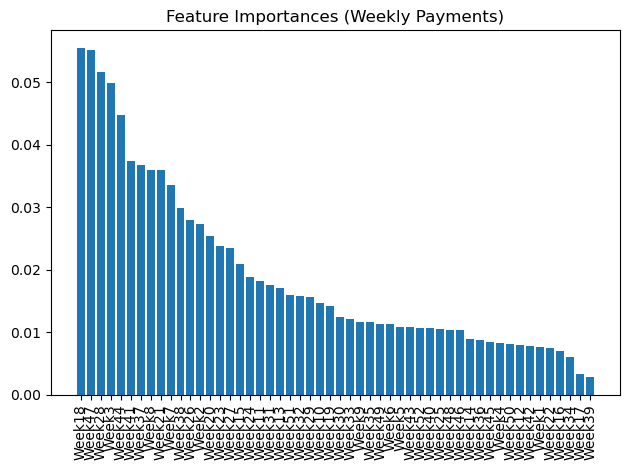

In [44]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score
from sklearn.model_selection import train_test_split
from scipy import stats
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv('Modified_StreetVendorsWeeklyTransactions.csv')
print(df)

print("----------------------------------------------------------------------------------")

# Calculate the total payments for each vendor (sum of weekly payments)
df['Total_Payments'] = df.iloc[:, 1:53].sum(axis=1)

# Remove outliers using Z-score
z_scores = np.abs(stats.zscore(df['Total_Payments']))
df = df[(z_scores < 3)]  # Keep vendors within 3 standard deviations

# Determine eligibility (sum of weekly payments > ₹15,000)
df['Eligibility'] = np.where(df['Total_Payments'] > 15000, 1, 0)

# Show the top 10 eligible vendors
top_10_eligible = df[df['Eligibility'] == 1].nlargest(10, 'Total_Payments')
print("Top 10 Eligible Vendors:\n", top_10_eligible[['Vendor No.', 'Total_Payments']])

# Calculate the total payments for each non-eligible vendor (sum of weekly payments)
df['Total_Payments'] = df.iloc[:, 1:53].sum(axis=1)

# Filter the non-eligible vendors (Eligibility == 0)
non_eligible_vendors = df[df['Eligibility'] == 0]

# Get the top 10 non-eligible vendors based on their total payments
top_10_non_eligible = non_eligible_vendors.nlargest(10, 'Total_Payments')

# Display the top 10 non-eligible vendors and their total payments
print("Top 10 Non-Eligible Vendors and Their Total Payments:\n")
print(top_10_non_eligible[['Vendor No.', 'Total_Payments']])

print("---------------------------------------------------------------------------------")

# Count the number of eligible and non-eligible vendors
num_eligible = df[df['Eligibility'] == 1].shape[0]
num_non_eligible = df[df['Eligibility'] == 0].shape[0]
total_vendors = df.shape[0]

print(f"Number of Eligible Vendors: {num_eligible}")
print(f"Number of Non-Eligible Vendors: {num_non_eligible}")
print(f"Total Number of Vendors: {total_vendors}")


print("-------------------------------------------------------------------------------")

# Split the data into features (X) and labels (y)
X = df.iloc[:, 1:53]  # Weekly payments as features
y = df['Eligibility']

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the Random Forest Classifier
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train, y_train)

# Predict on the test set
y_pred = clf.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)

print(f"Accuracy: {accuracy}")
print(f"F1 Score: {f1}")
print(f"Recall: {recall}")
print(f"Precision: {precision}")

print("_____________________________________________________________________")
# Loan repayment period
REPAYMENT_PERIOD = 10
print(f"Loan Repayment Period: {REPAYMENT_PERIOD} Month")
print("______________________________________________________________________")
# Visualize feature importance
importances = clf.feature_importances_
indices = np.argsort(importances)[::-1]
plt.figure()
plt.title("Feature Importances (Weekly Payments)")
plt.bar(range(X.shape[1]), importances[indices], align="center")
plt.xticks(range(X.shape[1]), X.columns[indices], rotation=90)
plt.tight_layout()
plt.show()


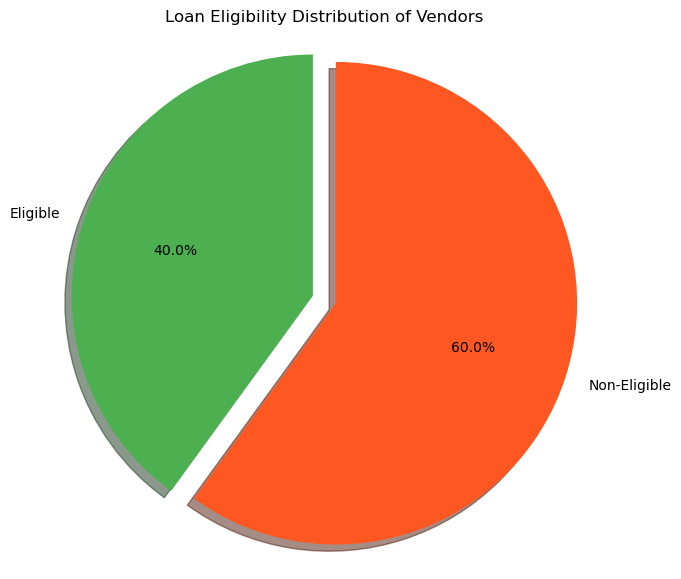

In [41]:
import matplotlib.pyplot as plt

# Count the number of eligible and non-eligible vendors
num_eligible = df[df['Eligibility'] == 1].shape[0]
num_non_eligible = df[df['Eligibility'] == 0].shape[0]

# Data for the pie chart
labels = ['Eligible', 'Non-Eligible']
sizes = [num_eligible, num_non_eligible]
colors = ['#4CAF50', '#FF5722']  # Green for eligible, Orange for non-eligible
explode = (0.1, 0)  # Explode the 'Eligible' section for emphasis

# Plotting the pie chart
plt.figure(figsize=(7,7))
plt.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%', shadow=True, startangle=90)
plt.axis('equal')  # Equal aspect ratio ensures that the pie is drawn as a circle.

# Display the chart
plt.title('Loan Eligibility Distribution of Vendors')
plt.show()

In [31]:
df.head(10)

,Vendor No.,Week1,Week2,Week3,Week4,Week5,Week6,Week7,Week8,Week9,...,Week45,Week46,Week47,Week48,Week49,Week50,Week51,Week52,Total_Payments,Eligibility
0,1,395,463,447,317,593,494,450,422,486,...,584,394,577,518,388,371,546,428,24427,1
1,2,381,129,139,53,398,230,482,472,369,...,479,220,267,131,99,195,364,473,15718,1
2,3,214,220,240,164,119,156,145,235,109,...,157,192,291,202,239,106,227,154,10335,0
3,4,205,161,189,197,176,282,218,135,188,...,214,198,146,170,265,166,161,208,10568,0
4,5,222,450,386,302,217,237,315,428,324,...,250,180,165,316,93,110,430,132,13409,0
5,6,598,463,357,568,357,587,404,527,546,...,343,581,474,461,439,431,386,475,24545,1
6,7,325,425,352,497,598,487,485,597,503,...,315,578,434,325,311,371,432,405,23364,1
7,8,266,136,218,185,225,235,151,190,132,...,275,239,195,188,202,245,105,221,10651,0
8,9,371,267,477,170,352,54,382,413,204,...,87,448,359,229,426,109,74,76,14119,0
9,10,270,215,262,281,161,296,243,235,188,...,222,153,271,133,298,221,212,161,10966,0
